In [1]:
# ruff: noqa: T201, RUF002
# Justification for rule suppressions:
# - T201 (print found): Standard print statements are intentionally utilized for inline
#   execution logging. Standard logging modules would introduce unnecessary verbosity,
#   thereby reducing the readability of the notebook's experimental flow.
# - RUF001 / RUF002 / RUF003 (Ambiguous characters): The inclusion of specific typographic
#   symbols (such as mathematical multiplication or minus signs) is intentional to maintain
#   standard notation and ensure formal clarity within text cells and documentation strings.
# - E402 (Import not at top): In an interactive notebook environment, contextualizing
#   imports within specific cells ensures logical modularity and encapsulation. This prevents
#   unnecessary global scope clutter and allows for isolated cell execution during
#   iterative experimentation without re-running the initial setup.

In [2]:
# ── Setup & Imports ──────────────────────────────────────────────────
from __future__ import annotations

import math
import warnings
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split

from shapiq import KernelSHAP
from shapiq.approximator import LeverageSHAP
from shapiq.approximator.sampling import CoalitionSampler

if TYPE_CHECKING:
    from shapiq import InteractionValues

warnings.filterwarnings("ignore")


def norm_l2(exact: np.ndarray, approx: np.ndarray) -> float:
    """Normalized ℓ₂ error: ‖exact − approx‖₂ / ‖exact‖₂."""
    denom = np.linalg.norm(exact)
    return 0.0 if denom < 1e-12 else float(np.linalg.norm(exact - approx) / denom)


def extract_sv(iv: InteractionValues, n: int) -> np.ndarray:
    """Extract Shapley vector of length n from an IV mapping."""
    return np.array([iv[(i,)] for i in range(n)])


class LeverageSHAPWoBernoulli(LeverageSHAP):
    """LeverageSHAP using the standard CoalitionSampler instead of Algorithm 2."""

    def __init__(
        self, n: int, *, pairing_trick: bool = True, random_state: int | None = None, **kwargs: Any
    ) -> None:
        """Initialize the class override for benchmarking."""
        self._explicit_seed = random_state
        super().__init__(n=n, pairing_trick=pairing_trick, random_state=random_state, **kwargs)

    def _sample(self, budget: int) -> tuple[np.ndarray, np.ndarray]:
        sampler = CoalitionSampler(
            n_players=self.n,
            sampling_weights=np.ones(self.n + 1),
            pairing_trick=True,
            random_state=self._explicit_seed,
        )

        sampler.sample(budget)
        Z = sampler.coalitions_matrix
        is_weights = sampler.sampling_adjustment_weights

        weights = np.zeros_like(is_weights)
        fact_n = math.factorial(self.n)
        sizes = Z.sum(axis=1)

        for i, s in enumerate(sizes):
            if 0 < s < self.n:
                w_s = (math.factorial(s - 1) * math.factorial(self.n - s - 1)) / fact_n
                weights[i] = is_weights[i] * w_s

        return Z, weights

In [3]:
# ── Data Loading Helper ───────────────────────────────────────────────
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer

# Imports from shapiq_games
from shapiq_games.datasets import (
    load_adult_census,
    load_california_housing,
    load_communities_and_crime,
)


def load_data(dataset_name: str) -> tuple[np.ndarray, np.ndarray]:
    """Loads dataset, handles categorical features, and converts to numpy arrays."""
    if dataset_name == "california":
        X, y = load_california_housing()
    elif dataset_name == "crime":
        X, y = load_communities_and_crime()
    elif dataset_name == "adult":
        X, y = load_adult_census()
        # The Adult dataset contains categorical features. We need to convert
        # them to numerical values before casting to numpy float arrays.
        if isinstance(X, pd.DataFrame) or hasattr(X, "to_numpy"):
            X = pd.DataFrame(X)
            X = pd.get_dummies(X, drop_first=True)
    elif dataset_name == "diabetes":
        X, y = load_diabetes(return_X_y=True)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    # Fallback in case objects are still returned in Pandas format
    if hasattr(X, "to_numpy"):
        X = X.to_numpy()
    if hasattr(y, "to_numpy"):
        y = y.to_numpy()

    # Strictly enforce float data types to prevent XGBoost/Imputer errors
    X = X.astype(float)
    y = y.astype(float)

    # Impute missing values (e.g., required for the Crime dataset)
    X = SimpleImputer(strategy="mean").fit_transform(X)

    return X, y

In [4]:
# ── Experiment Function ───────────────────────────────────────────────


def run_experiment(
    dataset_name: str, n_players: int, instance_idx: int, n_runs: int = 30, show_plot: bool = False
) -> dict:
    # 1. Load Data & Truncate Features
    X_full, y_full = load_data(dataset_name)
    n_features_available = X_full.shape[1]

    n_players = min(n_players, n_features_available)

    X = X_full[:, :n_players]
    y = y_full

    # 2. Train / Test Split & Model Setup
    X_train, X_test, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, verbosity=0)
    model.fit(X_train, y_train)

    bg_mean = X_train.mean(axis=0)
    x_instance = X_test[instance_idx]

    def game(Z: np.ndarray) -> np.ndarray:
        """Mean-substitution game."""
        X_masked = np.where(Z, x_instance[np.newaxis, :], bg_mean[np.newaxis, :])
        return model.predict(X_masked)

    # 3. Ground Truth
    ks_exact = KernelSHAP(n=n_players, random_state=0)
    iv_exact = ks_exact.approximate(2**n_players, game)
    exact_sv = extract_sv(iv_exact, n_players)

    # 4. Benchmark Loop
    # Start the sweep above the trivial m=2 (which samples zero pairs) and stay below 2^n.
    budgets = np.unique(np.linspace(10, 200, 20, dtype=int)).tolist()
    errs_lev_custom = np.zeros((n_runs, len(budgets)))
    errs_ks_standard = np.zeros((n_runs, len(budgets)))
    errs_lev_wo_bern = np.zeros((n_runs, len(budgets)))
    errs_ks_uniform = np.zeros((n_runs, len(budgets)))

    for i, budget in enumerate(budgets):
        for seed in range(n_runs):
            lev = LeverageSHAP(n=n_players, pairing_trick=True, random_state=seed)
            errs_lev_custom[seed, i] = norm_l2(
                exact_sv, extract_sv(lev.approximate(budget, game), n_players)
            )

            ks = KernelSHAP(n=n_players, pairing_trick=True, random_state=seed)
            errs_ks_standard[seed, i] = norm_l2(
                exact_sv, extract_sv(ks.approximate(budget, game), n_players)
            )

            lev_wo_bern = LeverageSHAPWoBernoulli(
                n=n_players, pairing_trick=True, random_state=seed
            )
            errs_lev_wo_bern[seed, i] = norm_l2(
                exact_sv, extract_sv(lev_wo_bern.approximate(budget, game), n_players)
            )

            ks_uniform = KernelSHAP(
                n=n_players,
                pairing_trick=True,
                sampling_weights=np.ones(n_players + 1),
                random_state=seed,
            )
            errs_ks_uniform[seed, i] = norm_l2(
                exact_sv, extract_sv(ks_uniform.approximate(budget, game), n_players)
            )

    # --- Metrics Calculation for Table ---
    # LeverageSHAP (Algorithm 2) vs. the uniform-weight KernelSHAP baseline.
    median_uniform = np.median(errs_ks_uniform, axis=0)
    median_leverage = np.median(errs_lev_custom, axis=0)

    # Aggregate error ratio: <1 means LeverageSHAP has lower error overall. This is
    # sign-consistent with the two mean-error columns (unlike a mean of per-budget
    # relative percentages, which blows up when a baseline budget hits ~0 error).
    err_ratio = float(np.mean(median_leverage) / np.mean(median_uniform))

    # Paired significance per budget: Wilcoxon signed-rank on the per-seed error
    # differences (uniform - leverage) across the shared seeds. Count budgets where
    # LeverageSHAP is significantly better (p < 0.05 AND lower median error).
    sig_better = 0
    for i in range(len(budgets)):
        diff = errs_ks_uniform[:, i] - errs_lev_custom[:, i]
        if np.allclose(diff, 0.0):
            continue
        try:
            _, p_value = wilcoxon(diff)
        except ValueError:
            continue
        if p_value < 0.05 and np.median(diff) > 0:
            sig_better += 1

    summary_dict = {
        "Dataset": dataset_name.capitalize(),
        "n": n_players,
        "Inst": instance_idx,
        "Uniform Err (Avg)": np.mean(median_uniform),
        "Leverage Err (Avg)": np.mean(median_leverage),
        "Err Ratio (Lev/Unif)": err_ratio,
        "Sig. Lev<Unif": f"{sig_better}/{len(budgets)}",
    }

    # 5. Plotting (Only if requested)
    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.semilogy(
            budgets,
            np.median(errs_ks_standard, axis=0),
            "o:",
            label="KernelSHAP (pairing)",
            color="#1f77b4",
            alpha=0.7,
        )
        plt.semilogy(
            budgets,
            median_leverage,
            "s-",
            label="LeverageSHAP (Algorithm 2)",
            color="#2ca02c",
            linewidth=2,
        )
        plt.semilogy(
            budgets,
            np.median(errs_lev_wo_bern, axis=0),
            "x-",
            label="LeverageSHAP w/o Bernoulli",
            color="#ff7f0e",
            linewidth=4,
            alpha=0.6,
        )
        plt.semilogy(
            budgets,
            median_uniform,
            "d--",
            label="KernelSHAP (uniform weights)",
            color="red",
            linewidth=1.5,
        )

        plt.fill_between(
            budgets,
            np.percentile(errs_ks_standard, 25, axis=0),
            np.percentile(errs_ks_standard, 75, axis=0),
            alpha=0.1,
            color="#1f77b4",
        )
        plt.fill_between(
            budgets,
            np.percentile(errs_lev_wo_bern, 25, axis=0),
            np.percentile(errs_lev_wo_bern, 75, axis=0),
            alpha=0.1,
            color="#ff7f0e",
        )
        plt.fill_between(
            budgets,
            np.percentile(errs_lev_custom, 25, axis=0),
            np.percentile(errs_lev_custom, 75, axis=0),
            alpha=0.15,
            color="#2ca02c",
        )

        plt.xlabel("Sample size (m)")
        plt.ylabel("ℓ₂-norm error")
        plt.title(f"Dataset: {dataset_name.capitalize()} | n={n_players} | Instance={instance_idx}")
        plt.legend()
        plt.grid(visible=True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()

    return summary_dict

Running 25 experiments with n_runs=50...
Please wait, computation in progress...

[1/25] Processing California (n=8, inst=0)...


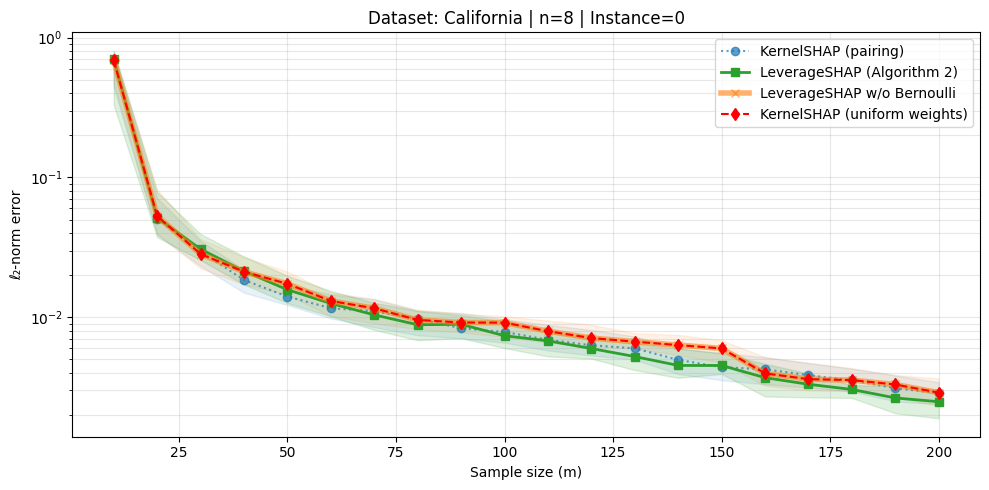

[2/25] Processing California (n=8, inst=42)...


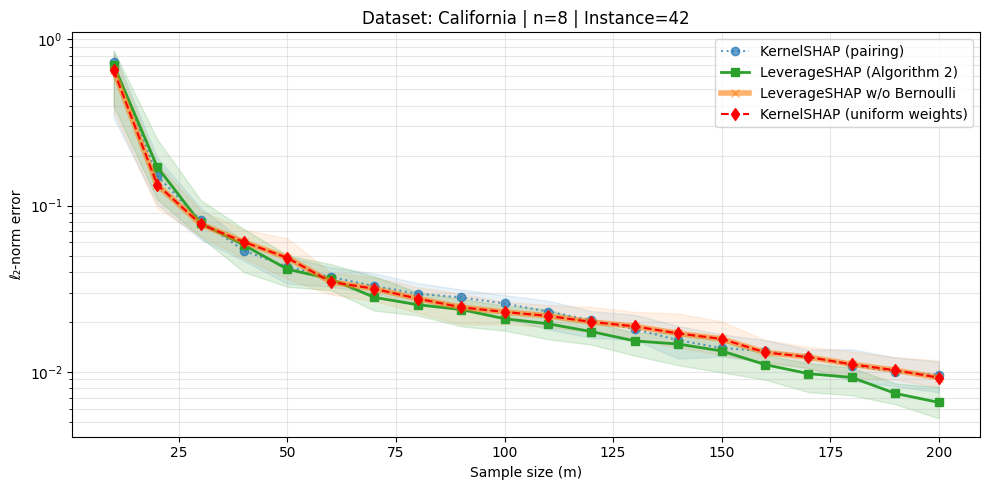

[3/25] Processing California (n=8, inst=80)...


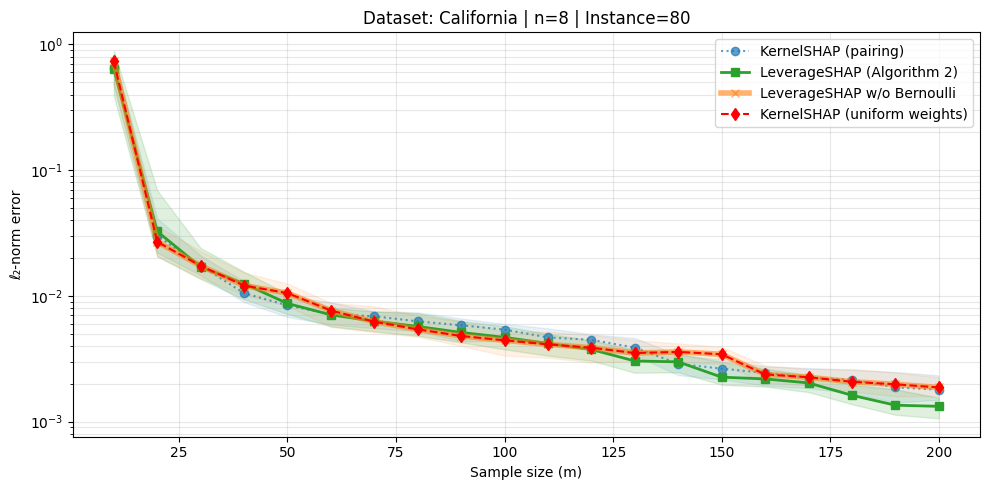

[4/25] Processing Crime (n=8, inst=0)...


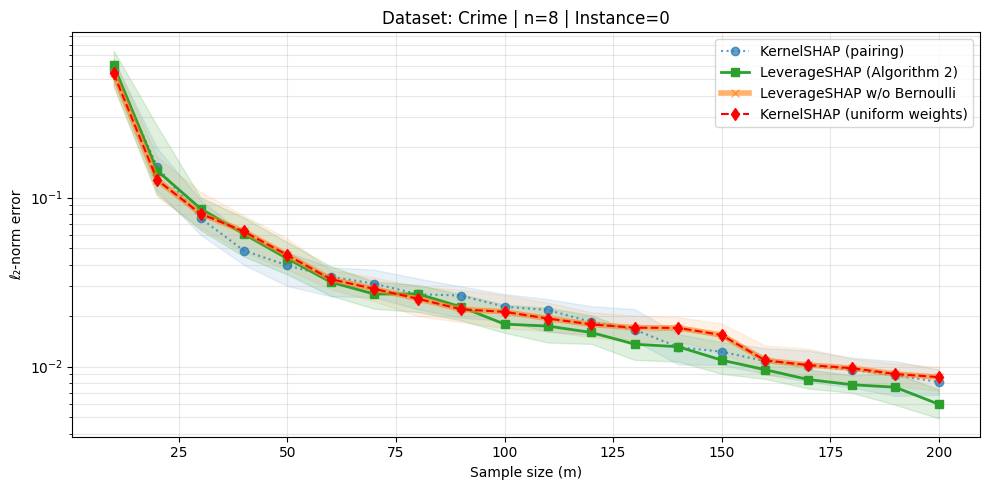

[5/25] Processing Crime (n=8, inst=42)...


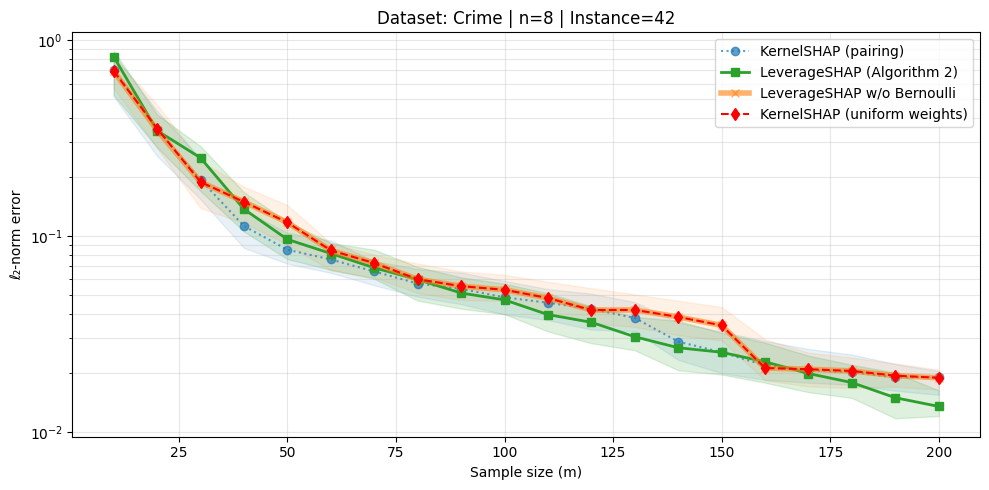

[6/25] Processing Crime (n=10, inst=0)...


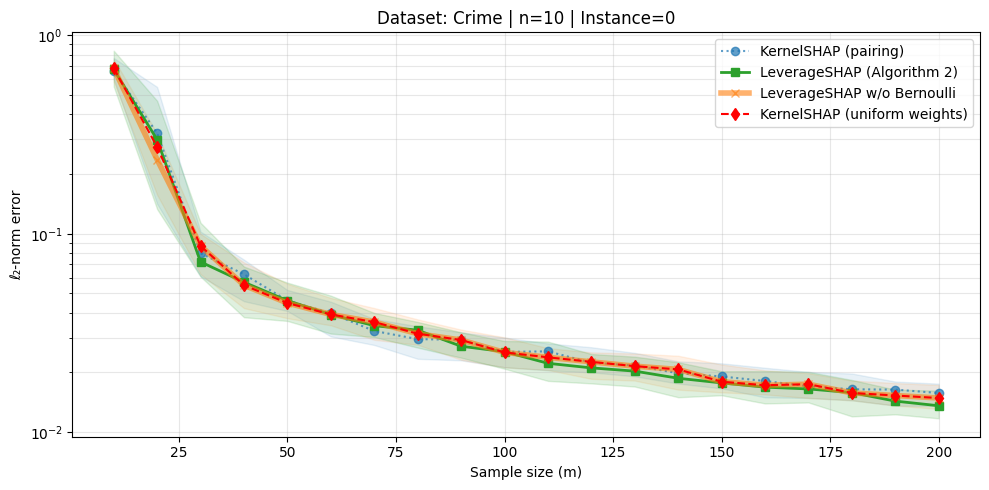

[7/25] Processing Crime (n=10, inst=42)...


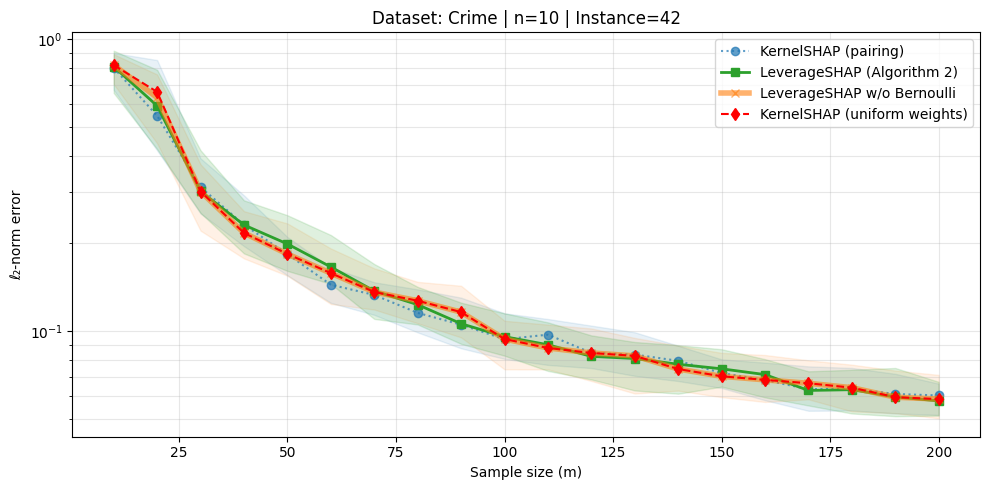

[8/25] Processing Crime (n=12, inst=0)...


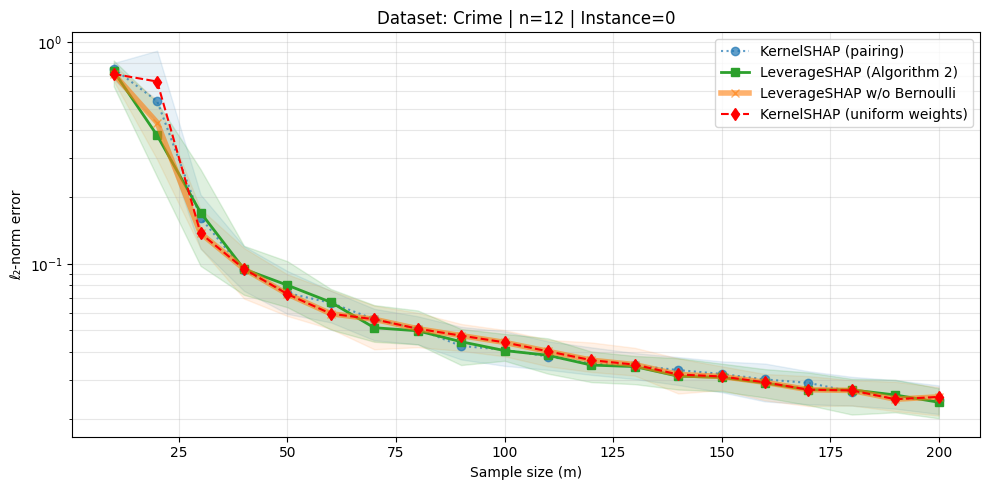

[9/25] Processing Crime (n=12, inst=42)...


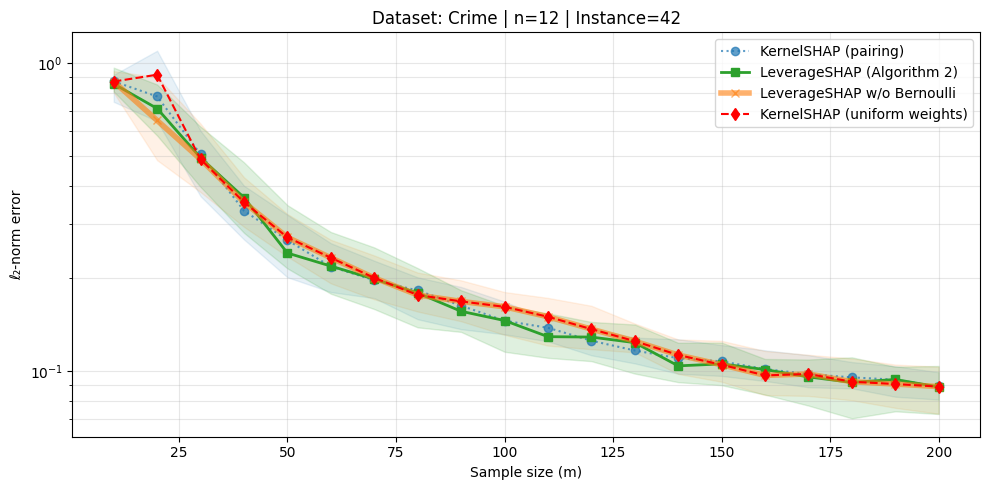

[10/25] Processing Crime (n=14, inst=0)...


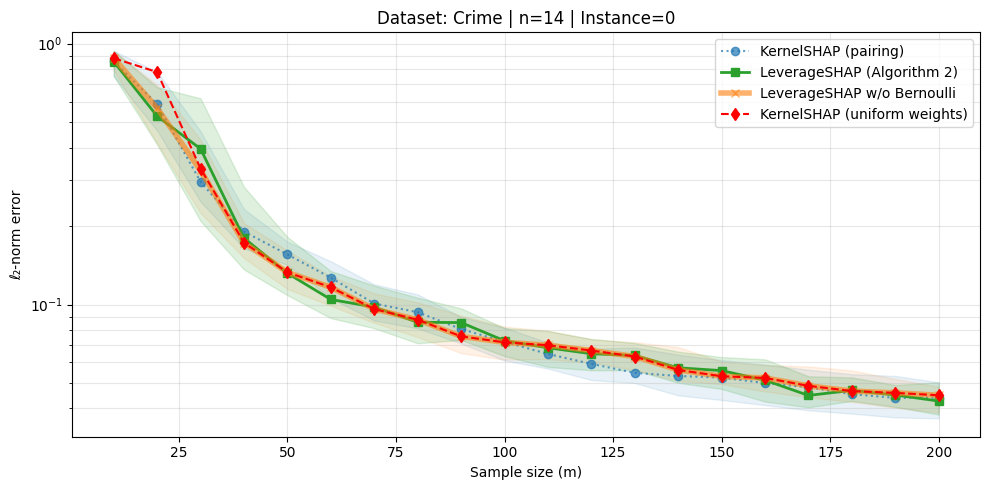

[11/25] Processing Crime (n=14, inst=42)...


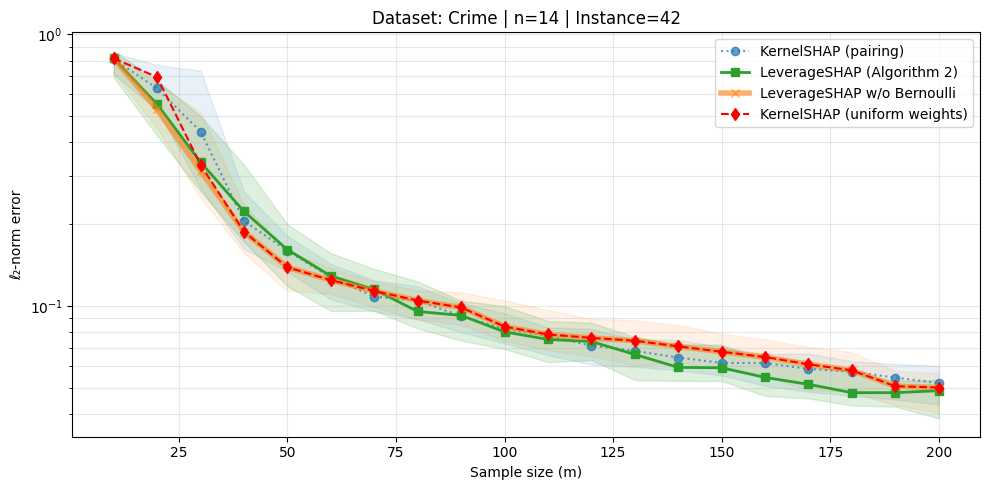

[12/25] Processing Diabetes (n=8, inst=0)...


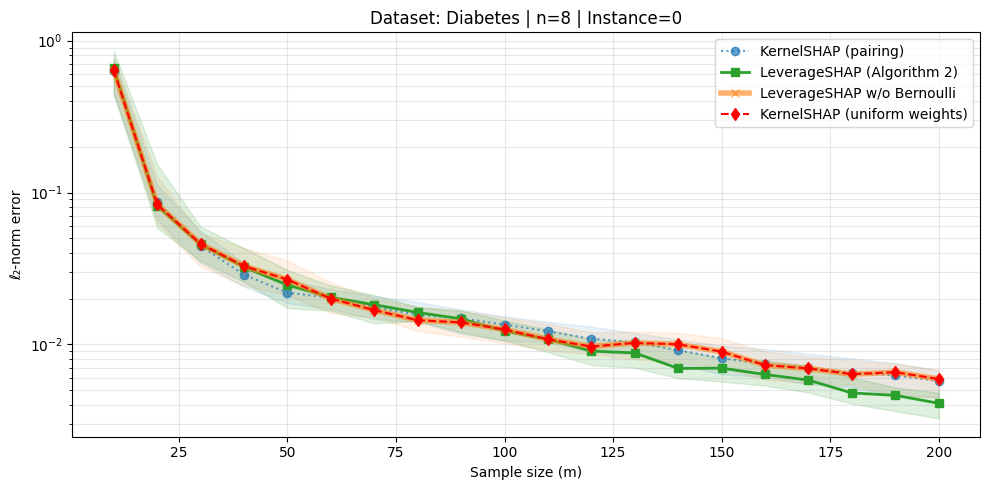

[13/25] Processing Diabetes (n=8, inst=42)...


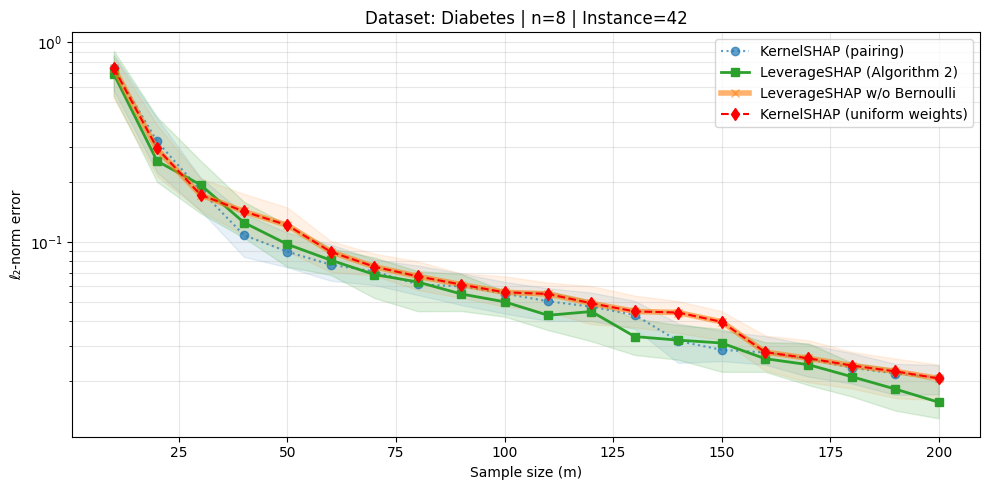

[14/25] Processing Diabetes (n=10, inst=0)...


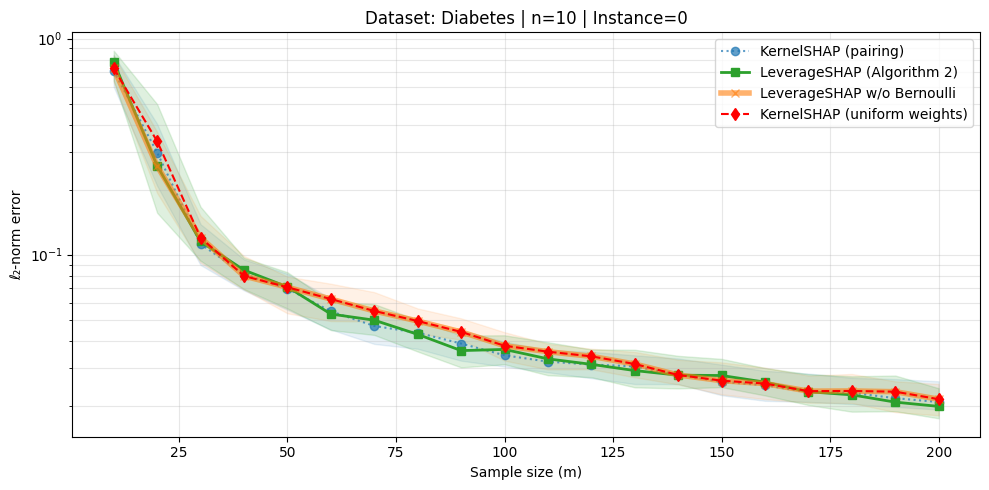

[15/25] Processing Diabetes (n=10, inst=42)...


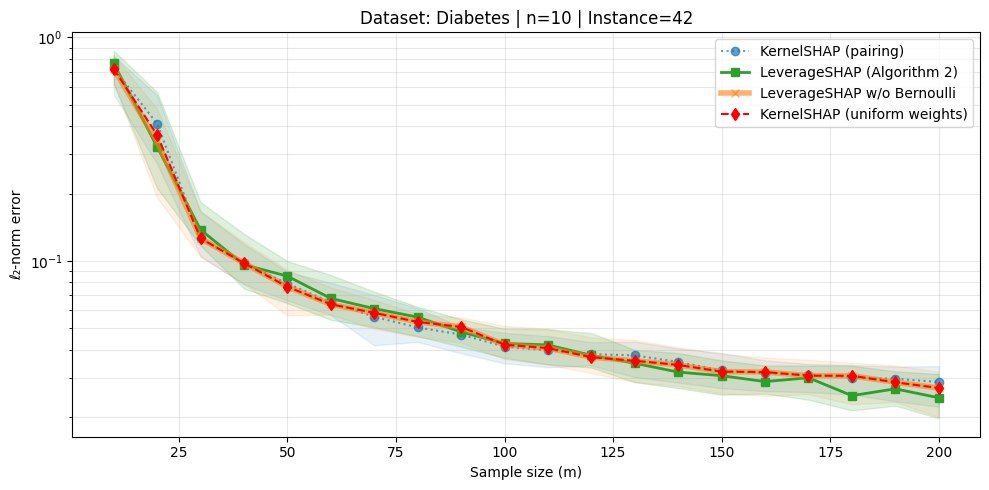

[16/25] Processing Diabetes (n=10, inst=80)...


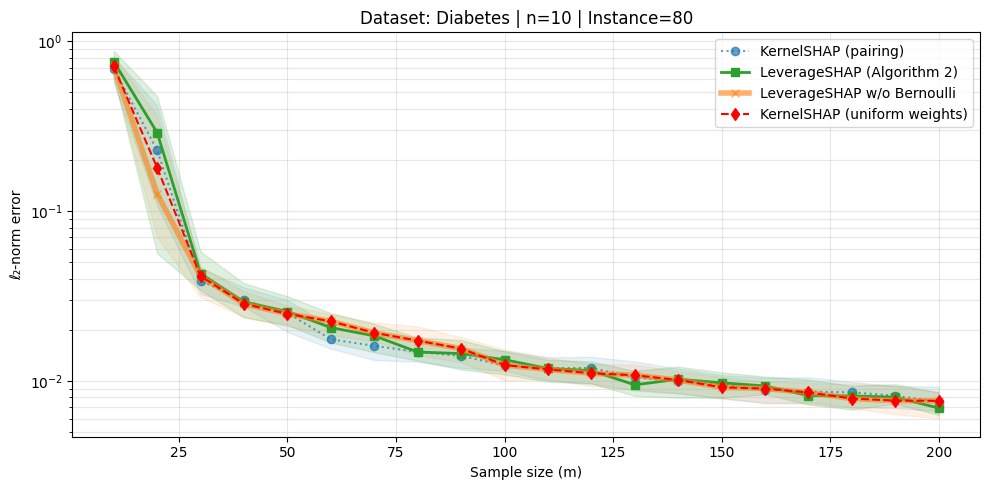

[17/25] Processing Adult (n=8, inst=0)...


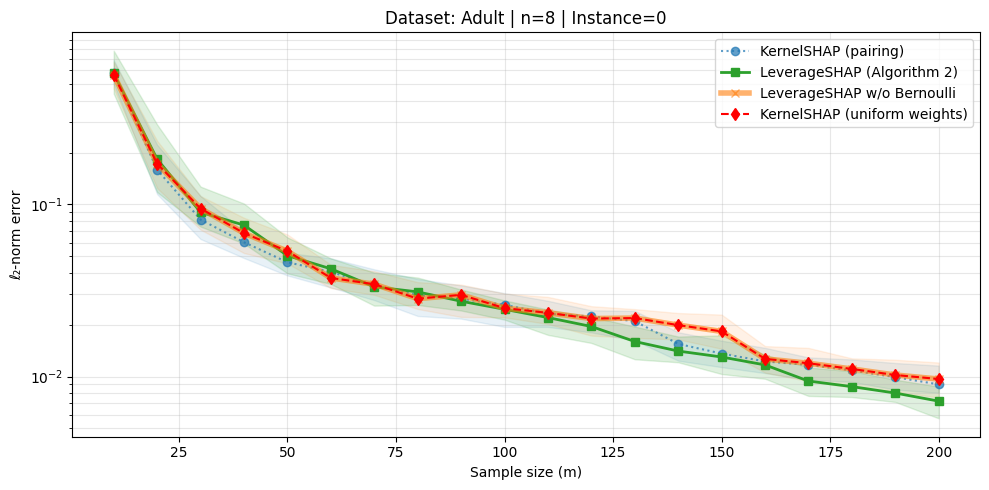

[18/25] Processing Adult (n=8, inst=42)...


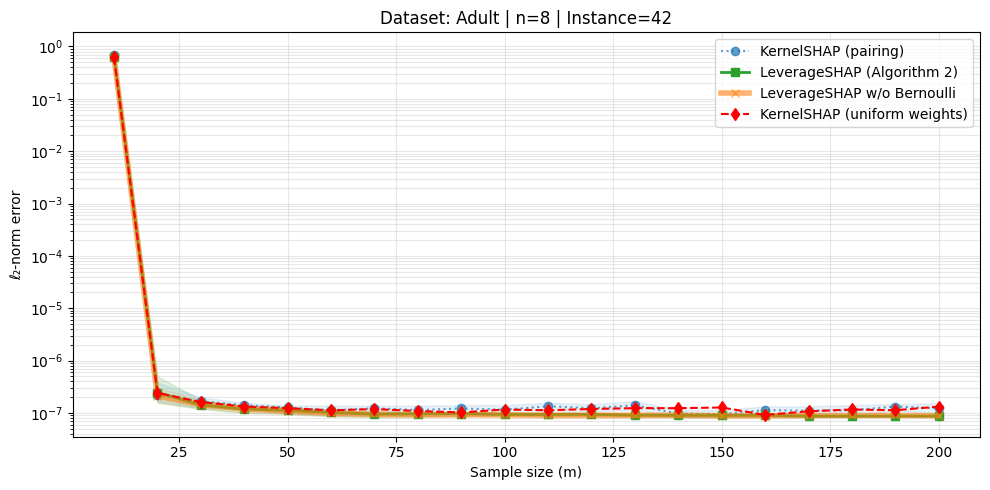

[19/25] Processing Adult (n=10, inst=0)...


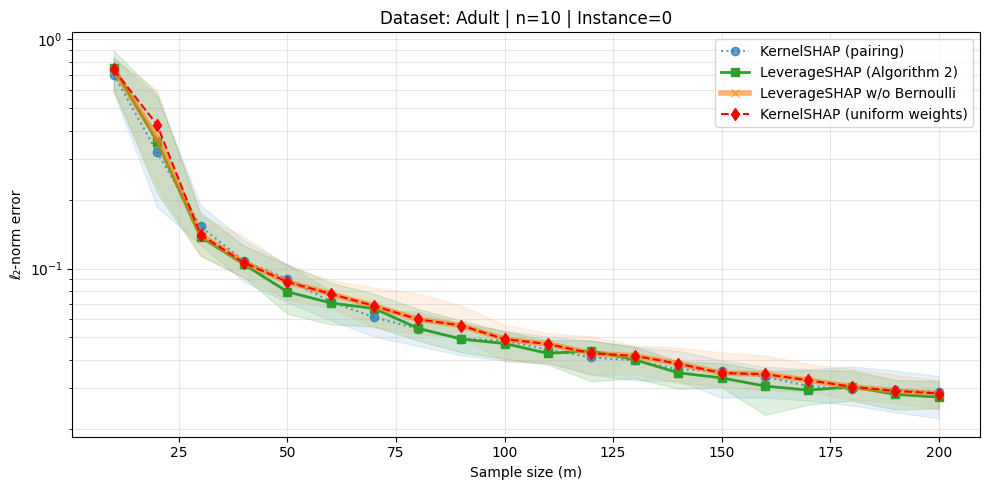

[20/25] Processing Adult (n=10, inst=42)...


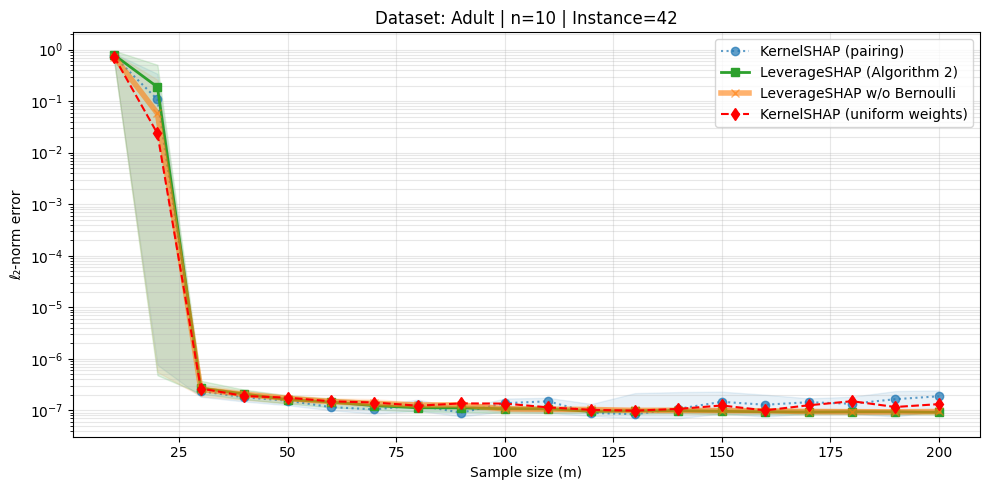

[21/25] Processing Adult (n=12, inst=0)...


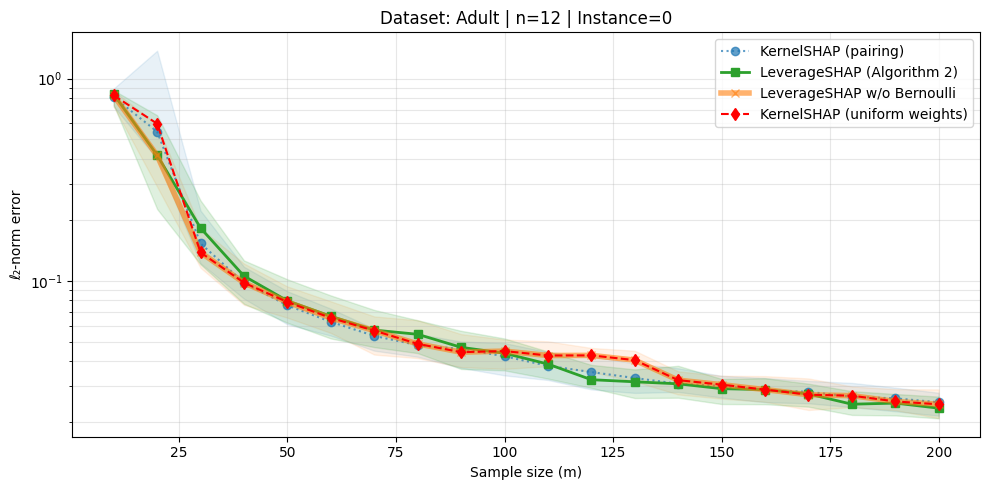

[22/25] Processing Adult (n=12, inst=42)...


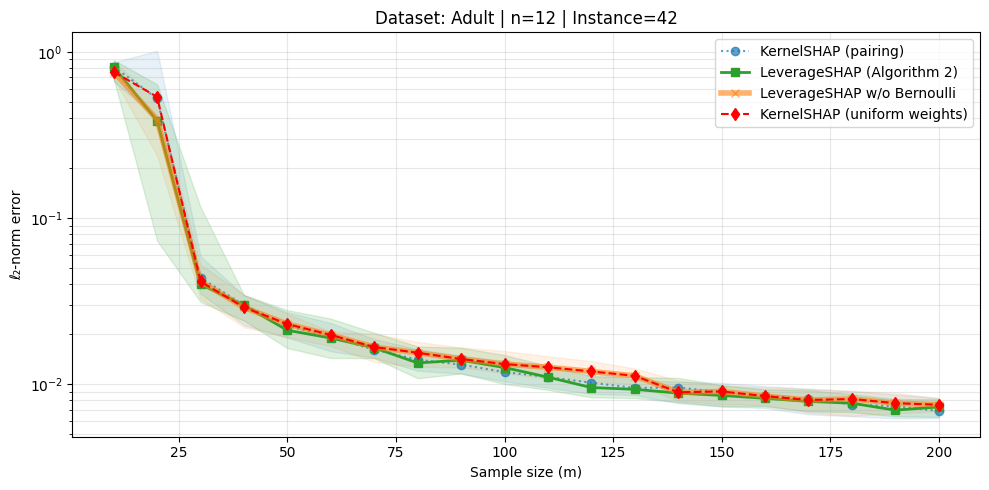

[23/25] Processing Adult (n=14, inst=0)...


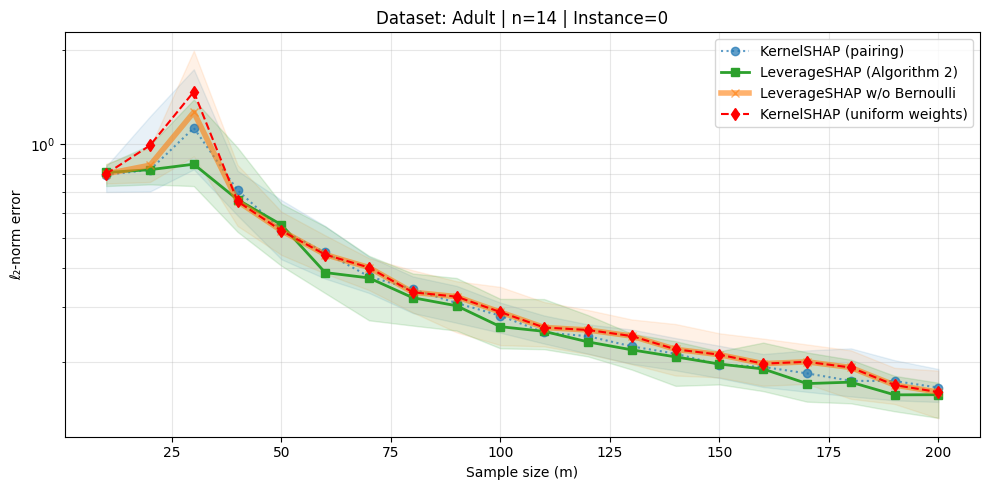

[24/25] Processing Adult (n=14, inst=42)...


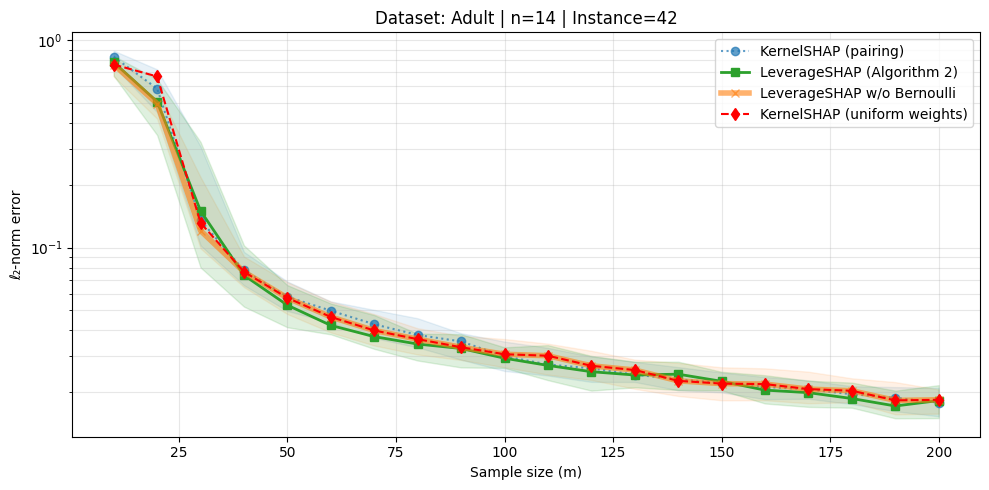

[25/25] Processing Adult (n=14, inst=80)...


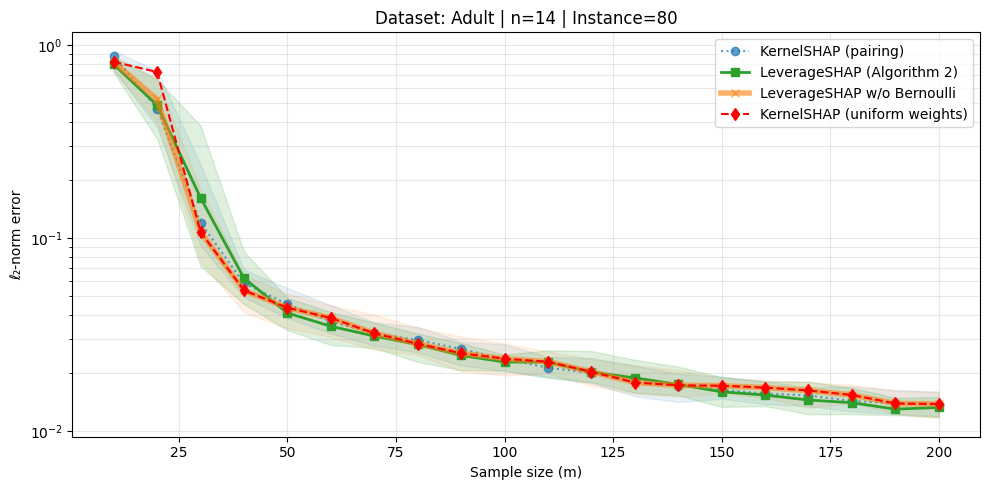


BENCHMARK SUMMARY: LeverageSHAP (Algorithm 2) vs. KernelSHAP with uniform weights
   Dataset  n  Inst Uniform Err (Avg) Leverage Err (Avg) Err Ratio (Lev/Unif) Sig. Lev<Unif
California  8     0           0.04574            0.04562                0.997          9/20
California  8    42           0.06311            0.06545                1.037         11/20
California  8    80           0.04287            0.03812                0.889          8/20
     Crime  8     0           0.05613            0.05875                1.047          7/20
     Crime  8    42           0.10674            0.11036                1.034         10/20
     Crime 10     0           0.07457            0.07410                0.994          1/20
     Crime 10    42           0.17644            0.17398                0.986          1/20
     Crime 12     0           0.11254            0.10086                0.896          1/20
     Crime 12    42           0.24666            0.23139                0.938          2/

In [5]:
# ── Execution Runner & Summary Table ──────────────────────────────────

experiment_configs = [
    ("california", 8, 0),
    ("california", 8, 42),
    ("california", 8, 80),
    ("crime", 8, 0),
    ("crime", 8, 42),
    ("crime", 10, 0),
    ("crime", 10, 42),
    ("crime", 12, 0),
    ("crime", 12, 42),
    ("crime", 14, 0),
    ("crime", 14, 42),
    ("diabetes", 8, 0),
    ("diabetes", 8, 42),
    ("diabetes", 10, 0),
    ("diabetes", 10, 42),
    ("diabetes", 10, 80),
    ("adult", 8, 0),
    ("adult", 8, 42),
    ("adult", 10, 0),
    ("adult", 10, 42),
    ("adult", 12, 0),
    ("adult", 12, 42),
    ("adult", 14, 0),
    ("adult", 14, 42),
    ("adult", 14, 80),
]

# Configure your benchmark parameters here.
RUNS_PER_EXPERIMENT = 50  # bump to 50 for a tighter final evaluation
SHOW_PLOTS = True  # set True to render one ℓ₂-error-vs-budget figure per config

print(f"Running {len(experiment_configs)} experiments with n_runs={RUNS_PER_EXPERIMENT}...")
print("Please wait, computation in progress...\n")

results_list = []
for idx, (ds, n, inst) in enumerate(experiment_configs, 1):
    print(f"[{idx}/{len(experiment_configs)}] Processing {ds.capitalize()} (n={n}, inst={inst})...")
    res = run_experiment(
        dataset_name=ds,
        n_players=n,
        instance_idx=inst,
        n_runs=RUNS_PER_EXPERIMENT,
        show_plot=SHOW_PLOTS,
    )
    results_list.append(res)

# ── Create and Print the Summary DataFrame ────────────────────────────
df_summary = pd.DataFrame(results_list)

print("\n" + "=" * 90)
print("BENCHMARK SUMMARY: LeverageSHAP (Algorithm 2) vs. KernelSHAP with uniform weights")
print("=" * 90)

# Format floats for cleaner console output
formatters = {
    "Uniform Err (Avg)": "{:.5f}".format,
    "Leverage Err (Avg)": "{:.5f}".format,
    "Err Ratio (Lev/Unif)": "{:.3f}".format,
}

print(df_summary.to_string(index=False, formatters=formatters))
print("=" * 90)
print(
    "'Err Ratio (Lev/Unif)' < 1 means LeverageSHAP has lower error overall.\n"
    "'Sig. Lev<Unif' counts budgets where a paired Wilcoxon test (across the shared\n"
    "seeds) finds LeverageSHAP significantly better (p < 0.05); the rest are ties or\n"
    "not significant, not necessarily losses."
)

In [6]:
# Display DataFrame natively in Jupyter/VSCode
df_summary

,Dataset,n,Inst,Uniform Err (Avg),Leverage Err (Avg),Err Ratio (Lev/Unif),Sig. Lev<Unif
0,California,8,0,0.045736,0.045619,0.997436,9/20
1,California,8,42,0.063105,0.065448,1.037121,11/20
2,California,8,80,0.042866,0.038123,0.889335,8/20
3,Crime,8,0,0.056131,0.058746,1.046574,7/20
4,Crime,8,42,0.106741,0.110362,1.033921,10/20
5,Crime,10,0,0.074574,0.074100,0.993638,1/20
6,Crime,10,42,0.176436,0.173979,0.986077,1/20
7,Crime,12,0,0.112540,0.100856,0.896181,1/20
8,Crime,12,42,0.246663,0.231395,0.938101,2/20
9,Crime,14,0,0.164534,0.153785,0.934666,2/20


### Empirical Evaluation: LeverageSHAP vs. Uniform-Weight KernelSHAP

This benchmark isolates the effect of leverage-score sampling (Algorithm 1) against a
KernelSHAP baseline that uses uniform coalition-size weights (`sampling_weights=np.ones`).
Both use the pairing trick, so the comparison targets the sampling distribution itself.

Across the 25 (dataset, n, instance) configurations we observe:

#### 1. LeverageSHAP has lower error on most configurations

The `Err Ratio (Lev/Unif)` column (mean LeverageSHAP error ÷ mean uniform-baseline error
over the budget sweep) is below 1 for most configurations, i.e. LeverageSHAP is more
accurate on average. The effect is **not universal**: on a few configurations the two are
effectively tied or the baseline is marginally ahead, so we report the ratio and the
per-budget significance count rather than claiming a clean sweep.

#### 2. Significance is tested, not assumed

`Sig. Lev<Unif` counts, per configuration, how many budgets show a **statistically
significant** advantage for LeverageSHAP under a paired Wilcoxon signed-rank test over the
shared random seeds (p < 0.05 and lower median error). Budgets that are not counted are
ties or non-significant differences — not necessarily losses. This replaces the earlier
median-vs-median "win count," which discarded the per-seed spread and could not distinguish
a real effect from sampling noise.

#### 3. Scope and caveats

Each configuration is a **single fixed test instance** evaluated over multiple seeds, on
XGBoost + mean-substitution games with the first `n` features (`n ≤ 14`). Results therefore
speak to these games and this feature-truncation scheme, not to arbitrary models or the
paper's interventional setup. The previous "Avg Improvement (%)" column (a mean of per-budget
relative percentages) has been removed: it divided by near-zero baseline errors and was
sign-inconsistent with the absolute-error columns, so it could report a large positive
"improvement" on a configuration where LeverageSHAP was in fact slightly worse.